# Normalizing Flows for image modeling

**Alejandro Lancho Serrano, Pablo Martínez Olmos, Vanessa Gómez Verdejo, Emilio Parrado Hernández**

Departamento de Teoría de la Señal y Comunicaciones

**Universidad Carlos III de Madrid**

<img src='https://upload.wikimedia.org/wikipedia/commons/8/88/Acronimo_nombre3l.jpg' width=300 />

**Based on the tutorial by Phillip Lippe:**
[![View notebook on Github](https://img.shields.io/static/v1.svg?logo=github&label=Repo&message=View%20On%20Github&color=lightgrey)](https://github.com/phlippe/uvadlc_notebooks/blob/master/docs/tutorial_notebooks/tutorial11/NF_image_modeling.ipynb)
[![Open In Collab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phlippe/uvadlc_notebooks/blob/master/docs/tutorial_notebooks/tutorial11/NF_image_modeling.ipynb)  
**Pre-trained models:**
[![View files on Github](https://img.shields.io/static/v1.svg?logo=github&label=Repo&message=View%20On%20Github&color=lightgrey)](https://github.com/phlippe/saved_models/tree/main/tutorial11)
[![GoogleDrive](https://img.shields.io/static/v1.svg?logo=google-drive&logoColor=yellow&label=GDrive&message=Download&color=yellow)](https://drive.google.com/drive/folders/1gttZ5DSrpKwn9g3RcizqA5qG7NFLMgvv?usp=sharing)   

# Introduction: Learning Normalizing Flows

In this tutorial, we are going to explore the intuition and practical implementation of **normalizing flows**, a class of generative models that allow us to model complex data distributions using invertible transformations.

While normalizing flows can be applied to many domains, we will focus on images throughout this tutorial because:
- Images provide a **visually intuitive** way to understand generative modeling.
- They are **high-dimensional and complex**, offering a good testbed for normalizing flows.
- Image datasets are widely available and easy to preprocess.

Our primary goal here is not to build state-of-the-art models, but to understand:
- **How normalizing flows work**.
- **How to build them step-by-step in code**.
- **How to visualize and interpret their behavior**.

We will intentionally keep our models **simple and small** to ensure that everything runs quickly on CPU, and that the concepts remain the main focus. If you want to scale up the models later, the ideas directly carry over.

This tutorial is **inspired by the excellent materials by Philip Lippe**, but has been adapted, simplified, and extended with additional visualizations and exercises to support an audience that may not have a research background in deep generative modeling.

Throughout the notebook, we will use **PyTorch** for implementation, and combine it minimally with PyTorch Lightning, so that we have full visibility into the mechanics of the flow models keeping it easy to implement as well.

---

 **Key principles of this notebook:**
- Clear intuition behind every concept.
- Step-by-step code construction.
- Visual demonstrations wherever possible.

---

Let's start by importing the libraries we will need throughout the notebook.

## Imports and Setup

In this cell, we import all necessary libraries and configure our environment. Since we want to fully understand how our models work, let's take a moment to walk through the most important components:

### Standard Python libraries:
- `os`: For filesystem interaction.
- `math`, `time`: Useful helper functions for math and timing.
- `numpy`: Popular library for numerical computations with arrays.

### Plotting and Visualization:
- `matplotlib.pyplot`: The main plotting library.
- `%matplotlib inline`: Ensures that plots are displayed inside the notebook.
- `IPython.display.set_matplotlib_formats`: Allows us to export plots in high-quality vector formats (SVG/PDF).
- `seaborn`: Adds additional styling options to matplotlib for prettier plots.

### Progress Monitoring:
- `tqdm`: Displays progress bars during loops for better feedback while training or evaluating models.

### PyTorch Core:
- `torch`, `torch.nn`, `torch.nn.functional`: Provide tensor operations, neural network layers, and functions.
- `torch.utils.data`: Utilities for data loading and batching.
- `torch.optim`: Optimization algorithms (e.g. Adam, SGD).

### TorchVision (for datasets & transforms):
- `torchvision.datasets`: Contains popular datasets like MNIST.
- `torchvision.transforms`: Provides image preprocessing functions.

### PyTorch Lightning (training framework):
- `pytorch_lightning`: Simplifies and structures PyTorch training code.
- We automatically install it if not available (useful for cloud or Colab usage).

### Paths:
- `DATASET_PATH`: Where datasets will be stored.
- `CHECKPOINT_PATH`: Where trained model checkpoints will be saved.

### Reproducibility:
- `pl.seed_everything(42)`: Ensures all random operations behave deterministically.
- `torch.backends.cudnn.deterministic = True`: Ensures deterministic behavior for CUDA kernels.
- `torch.backends.cudnn.benchmark = False`: Prevents nondeterministic optimizations.

### Device Configuration:
- Automatically selects GPU (`cuda:0`) if available; otherwise defaults to CPU.

---

With this, we have fully initialized our environment to start building and training normalizing flows in PyTorch.

In [ ]:
# Standard libraries
import os
import math
import time
import numpy as np

# Plotting libraries
import matplotlib.pyplot as plt
from IPython.display import set_matplotlib_formats
set_matplotlib_formats('svg', 'pdf')  # Higher quality plots for export
import matplotlib
matplotlib.rcParams['lines.linewidth'] = 2.0
from matplotlib.colors import to_rgb
import seaborn as sns

# Ensure seaborn doesn't throw config warnings
sns.set_theme()

# Progress bar
from tqdm.auto import tqdm

# PyTorch libraries
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.utils.data as data
import torch.optim as optim

# Torchvision (for datasets and transforms)
import torchvision
from torchvision.datasets import MNIST
from torchvision import transforms

# PyTorch Lightning
try:
    import pytorch_lightning as pl
except ModuleNotFoundError:
    import sys
    !{sys.executable} -m pip install --quiet pytorch-lightning>=1.4
    import pytorch_lightning as pl
from pytorch_lightning.callbacks import LearningRateMonitor, ModelCheckpoint

# Data paths
DATASET_PATH = "./data"
CHECKPOINT_PATH = "./saved_models"
os.makedirs(DATASET_PATH, exist_ok=True)
os.makedirs(CHECKPOINT_PATH, exist_ok=True)

# Seed for reproducibility
pl.seed_everything(42)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device", device)

/var/folders/jp/6dqt28x13gl0mvh7lthhyjxm0002jl/T/ipykernel_71437/1769292614.py:10: DeprecationWarning: `set_matplotlib_formats` is deprecated since IPython 7.23, directly use `matplotlib_inline.backend_inline.set_matplotlib_formats()`
  set_matplotlib_formats('svg', 'pdf')  # Higher quality plots for export
/opt/homebrew/Caskroom/miniconda/base/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Seed set to 42


Using device cpu


## Downloading Pretrained Models

To save time and computational resources, we provide a few pretrained models that we will use for evaluation and visualization throughout this tutorial. This allows us to explore how well trained normalizing flows can model image data, without requiring hours of training.

The following code downloads these pretrained models from a public GitHub repository and stores them in the `CHECKPOINT_PATH` directory we defined earlier.

In [12]:
import urllib.request
from urllib.error import HTTPError

# Github URL where saved models are stored for this tutorial
base_url = "https://raw.githubusercontent.com/phlippe/saved_models/main/tutorial11/"

# List of pretrained models to download
pretrained_files = [
    "MNISTFlow_simple.ckpt",
    "MNISTFlow_vardeq.ckpt",
    "MNISTFlow_multiscale.ckpt"
]

# Create checkpoint path if it doesn't exist yet
os.makedirs(CHECKPOINT_PATH, exist_ok=True)

# Download files if not already present
for file_name in pretrained_files:
    file_path = os.path.join(CHECKPOINT_PATH, file_name)
    if not os.path.isfile(file_path):
        file_url = base_url + file_name
        print(f"Downloading {file_url}...")
        try:
            urllib.request.urlretrieve(file_url, file_path)
        except HTTPError as e:
            print("Download failed. Please check your internet connection, or download manually from the repository.")
            print("Error message:", e)

## Loading the MNIST Dataset

For this tutorial, we will use the **MNIST dataset**, which consists of 70,000 images of handwritten digits (28x28 grayscale images).

Even though MNIST is often used as a simple benchmark for classification tasks, it poses interesting challenges for generative models because:
- It requires understanding both global structure (digit shape) and local details.
- Generated samples are easy to visually inspect for quality.

Since normalizing flows model continuous probability densities, we convert pixel values from the default range $[0,1]$ into discrete integers $[0,255]$. This better reflects the discrete nature of image data, and prepares us for using **dequantization** later on.

We also split the dataset into:
- **Training set**: 50,000 samples
- **Validation set**: 10,000 samples
- **Test set**: 10,000 samples

In [13]:
# Function to convert images from [0,1] floats to [0,255] integers
def discretize(sample):
    return (sample * 255).to(torch.int32)

# Compose transformation: convert to tensor + discretize
transform = transforms.Compose([
    transforms.ToTensor(),
    discretize
])

# Load full MNIST training set (60k samples)
train_dataset = MNIST(root=DATASET_PATH, train=True, transform=transform, download=True)

# Use a fixed seed to ensure reproducibility of train/val split
pl.seed_everything(42)
train_set, val_set = torch.utils.data.random_split(train_dataset, [50000, 10000])

# Load test set (10k samples)
test_set = MNIST(root=DATASET_PATH, train=False, transform=transform, download=True)

# Define data loaders (with slightly larger batches for training)
train_loader = data.DataLoader(train_set, batch_size=256, shuffle=False, drop_last=False)
val_loader = data.DataLoader(val_set, batch_size=64, shuffle=False, drop_last=False, num_workers=4)
test_loader = data.DataLoader(test_set, batch_size=64, shuffle=False, drop_last=False, num_workers=4)

Seed set to 42


## Visualizing Images and Samples

To better understand the dataset (and later inspect model generations), we define a helper function `show_imgs` that:
- Arranges images into a grid.
- Automatically handles both integer and float inputs.
- Displays the grid using matplotlib.

Let's visualize a few random samples from the training set to get familiar with the MNIST digits.

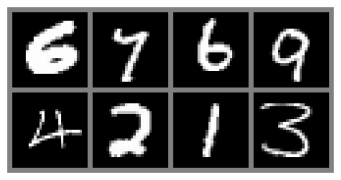

In [14]:
def show_imgs(imgs, title=None, row_size=4):
    # Determine number of images to display
    num_imgs = imgs.shape[0] if isinstance(imgs, torch.Tensor) else len(imgs)
    is_int = imgs.dtype==torch.int32 if isinstance(imgs, torch.Tensor) else imgs[0].dtype==torch.int32

    # Arrange images into grid
    nrow = min(num_imgs, row_size)
    ncol = int(math.ceil(num_imgs/nrow))
    imgs = torchvision.utils.make_grid(imgs, nrow=nrow, pad_value=128 if is_int else 0.5)

    # Convert to numpy array for plotting
    np_imgs = imgs.cpu().numpy()
    plt.figure(figsize=(1.5*nrow, 1.5*ncol))
    plt.imshow(np.transpose(np_imgs, (1,2,0)), interpolation='nearest')
    plt.axis('off')
    if title is not None:
        plt.title(title)
    plt.show()
    plt.close()

# Show 8 random images from the training set
show_imgs([train_set[i][0] for i in range(8)])

## Normalizing Flows as generative model

In the previous lectures, we have seen Variational Autoencoders (VAEs) and Generative Adversarial Networks (GANs) as example of generative models. However, none of them explicitly learn the probability density function $p(x)$ of the real input data. While VAEs model a lower bound, GANs provide us a sampling mechanism for generating new data, without offering a likelihood estimate. The generative model we will look at here, called Normalizing Flows, actually models the true data distribution $p(x)$ and provides us with an exact likelihood estimate. Below, we can visually compare VAEs, GANs and Flows
(figure credit - [Lilian Weng](https://lilianweng.github.io/lil-log/2018/10/13/flow-based-deep-generative-models.html)):

<center width="100%"><img src="https://github.com/phlippe/uvadlc_notebooks/blob/master/docs/tutorial_notebooks/tutorial11/comparison_GAN_VAE_NF.png?raw=1" width="600px"></center>

The major difference compared to VAEs is that flows use *invertible* functions $f$ to map the input data $x$ to a latent representation $z$. To realize this, $z$ must be of the same shape as $x$. This is in contrast to VAEs where $z$ is usually much lower dimensional than the original input data. However, an invertible mapping also means that for every data point $x$, we have a corresponding latent representation $z$ which allows us to perform lossless reconstruction ($z$ to $x$). In the visualization above, this means that $x=x'$ for flows, no matter what invertible function $f$ and input $x$ we choose.

Nonetheless, how are normalizing flows modeling a probability density with an invertible function? The answer to this question is the rule for change of variables. Specifically, given a prior density $p_z(z)$ (e.g. Gaussian) and an invertible function $f$, we can determine $p_x(x)$ as follows:

$$
\begin{split}
    \int p_x(x) dx & = \int p_z(z) dz = 1 \hspace{1cm}\text{(by definition of a probability distribution)}\\
    \Leftrightarrow p_x(x) & = p_z(z) \left|\frac{dz}{dx}\right| = p_z(f(x)) \left|\frac{df(x)}{dx}\right|
\end{split}
$$

Hence, in order to determine the probability of $x$, we only need to determine its probability in latent space, and get the derivate of $f$. Note that this is for a univariate distribution, and $f$ is required to be invertible and smooth. For a multivariate case, the derivative becomes a Jacobian of which we need to take the determinant. As we usually use the log-likelihood as objective, we write the multivariate term with logarithms below:

$$
\log p_x(\mathbf{x}) = \log p_z(f(\mathbf{x})) + \log{} \left|\det \frac{df(\mathbf{x})}{d\mathbf{x}}\right|
$$

Although we now know how a normalizing flow obtains its likelihood, it might not be clear what a normalizing flow does intuitively. For this, we should look from the inverse perspective of the flow starting with the prior probability density $p_z(z)$. If we apply an invertible function on it, we effectively "transform" its probability density. For instance, if $f^{-1}(z)=z+1$, we shift the density by one while still remaining a valid probability distribution, and being invertible. We can also apply more complex transformations, like scaling: $f^{-1}(z)=2z+1$, but there you might see a difference. When you scale, you also change the volume of the probability density, as for example on uniform distributions (figure credit - [Eric Jang](https://blog.evjang.com/2018/01/nf1.html)):

<center width="100%"><img src="https://github.com/phlippe/uvadlc_notebooks/blob/master/docs/tutorial_notebooks/tutorial11/uniform_flow.png?raw=1" width="300px"></center>

You can see that the height of $p(y)$ should be lower than $p(x)$ after scaling. This change in volume represents $\left|\frac{df(x)}{dx}\right|$ in our equation above, and ensures that even after scaling, we still have a valid probability distribution. We can go on with making our function $f$ more complex. However, the more complex $f$ becomes, the harder it will be to find the inverse $f^{-1}$ of it, and to calculate the log-determinant of the Jacobian $\log{} \left|\det \frac{df(\mathbf{x})}{d\mathbf{x}}\right|$. An easier trick to stack multiple invertible functions $f_{1,...,K}$ after each other, as all together, they still represent a single, invertible function. Using multiple, learnable invertible functions, a normalizing flow attempts to transform $p_z(z)$ slowly into a more complex distribution which should finally be $p_x(x)$. We visualize the idea below
(figure credit - [Lilian Weng](https://lilianweng.github.io/lil-log/2018/10/13/flow-based-deep-generative-models.html)):

<center width="100%"><img src="https://github.com/phlippe/uvadlc_notebooks/blob/master/docs/tutorial_notebooks/tutorial11/normalizing_flow_layout.png?raw=1" width="700px"></center>

Starting from $z_0$, which follows the prior Gaussian distribution, we sequentially apply the invertible functions $f_1,f_2,...,f_K$, until $z_K$ represents $x$. Note that in the figure above, the functions $f$ represent the inverted function from $f$ we had above (here: $f:Z\to X$, above: $f:X\to Z$). This is just a different notation and has no impact on the actual flow design because all $f$ need to be invertible anyways. When we estimate the log likelihood of a data point $x$ as in the equations above, we run the flows in the opposite direction than visualized above. Multiple flow layers have been proposed that use a neural network as learnable parameters, such as the planar and radial flow. However, we will focus here on flows that are commonly used in image modeling, and will discuss them in the rest of the notebook along with the details of how to train a normalizing flow.

## Understanding Normalizing Flows

Before diving into how normalizing flows work, let's briefly remind ourselves how they compare to other popular generative models already seen in this course:

- **GANs (Generative Adversarial Networks):**  
  Allow us to generate realistic data samples, but don't give us an explicit probability for a given data point. They train via a minimax game between a generator and a discriminator.
  
- **VAEs (Variational Autoencoders):**  
  Provide a lower bound estimate of the likelihood (the ELBO), but not the exact likelihood itself. The latent space is typically lower-dimensional than the input.

- **Normalizing Flows (our topic):**  
  Fully model the data distribution $p(x)$ and allow us to compute **exact likelihoods** for any input. They achieve this by using a sequence of invertible, learnable transformations.

We summarize these differences visually below:

<center><img src="https://github.com/phlippe/uvadlc_notebooks/blob/master/docs/tutorial_notebooks/tutorial11/comparison_GAN_VAE_NF.png?raw=1" width="600px"></center>

---

### The core idea of flows

The key concept behind normalizing flows is to transform a simple, known distribution into a complex one by using an **invertible function**.

- We start with a simple latent distribution $p(z)$ (e.g. Gaussian).
- We apply a sequence of invertible transformations to map samples from latent space to data space.

Since these transformations are invertible, we can also map data points $x$ into latent space, and compute their exact likelihood.

---

### The change of variables rule

How do we compute $p(x)$ once we apply a transformation $f$ to $x$?

We use the **change of variables formula** from probability theory:

For a 1D transformation:

\begin{align}
p_x(x) &= p_z(z) \cdot \left| \frac{dz}{dx} \right| \\
&= p_z(f(x)) \cdot \left| \frac{df(x)}{dx} \right|
\end{align}

For higher-dimensional data, we use the **Jacobian matrix** of $f$:

\begin{equation}
\log p_x(\mathbf{x}) = \log p_z(f(\mathbf{x})) + \log \left| \det \frac{d f(\mathbf{x})}{d \mathbf{x}} \right|
\end{equation}

This formula shows us that computing the likelihood consists of:
- Evaluating the latent density $p_z(f(x))$
- Calculating the determinant of the Jacobian of $f$

---

### Intuition for volume changes

What does the Jacobian determinant mean?

Intuitively, it captures how much the transformation **stretches or compresses** the space.

- If $f$ only shifts data (e.g., $f(x) = x+1$), the volume stays the same: $\det J = 1$.
- If $f$ scales the data (e.g., $f(x) = 2x+1$), the volume changes, and the density must adjust accordingly.

You can see this effect in the example below (scaling a uniform distribution):

<center><img src="https://blogger.googleusercontent.com/img/b/R29vZ2xl/AVvXsEiRGNBOlzdMg6krBIj1cSqgXB9rintNXu6kIY71cPQVuiSllaYHdOoLqFqp73CQhHOAAfaX83HQ2quM6ivXgfjJBA-fErZeLil01qo4W3JgUbjYVUi3Hb7T41NCSs83hHMgNTVW1HnbU34/s400/flow1.png" width="300px"></center>

Without correcting for volume change, we would no longer have a valid probability distribution.

---

### Composing multiple transformations

In practice, instead of designing one complicated invertible function, we compose several simple ones:

$$
\mathbf{z}_0 \xrightarrow{f_1} \mathbf{z}_1 \xrightarrow{f_2} \cdots \xrightarrow{f_K} \mathbf{z}_K = \mathbf{x}
$$

Each $f_i$ is invertible, so the entire composition remains invertible. This makes it easier to design, train, and compute the Jacobians.

We visualize this process below:

<center><img src="https://github.com/phlippe/uvadlc_notebooks/blob/master/docs/tutorial_notebooks/tutorial11/normalizing_flow_layout.png?raw=1" width="700px"></center>

- We start with latent variables $z_0 \sim p_0(z)$ (usually Gaussian).
- After multiple transformations, we obtain $z_K$, which represents data samples $x$.

---

### Why invertibility matters

Because flows are invertible:

- We can compute the exact likelihood of any data point $x$.
- We can generate new samples easily by drawing $z \sim p(z)$ and applying the inverse transformations.

This is different from VAEs (which require approximate inference) and GANs (which cannot compute likelihoods at all).

---

### Summary so far

- Flows give us **exact likelihoods** by applying invertible transformations.
- The Jacobian determinant adjusts for volume changes in these transformations.
- By composing several simple invertible layers, we can approximate very complex data distributions.

In the next sections, we will explore specific types of invertible transformations that make normalizing flows practical and computationally efficient.

## The ImageFlow Model: Wrapping the Full Flow Architecture

In this section, we define the main model class `ImageFlow`, which manages:

- The full **composition of flow layers**.
- Likelihood computation and log-likelihood training.
- Inverse transformations for **sampling**.
- Optimizer configuration and Lightning integration.

While individual flows are implemented as small, invertible blocks, this class connects them all into a complete generative model.

Let's carefully go through its components.

In [ ]:
class ImageFlow(pl.LightningModule):
    def __init__(self, flows, import_samples=8):
        """
        Inputs:
            flows: list of flow layers (each being invertible nn.Modules)
            import_samples: number of importance samples used during testing (for more stable evaluation)
        """
        super().__init__()
        self.flows = nn.ModuleList(flows)
        self.import_samples = import_samples
        
        # Standard normal prior p(z)
        self.prior = torch.distributions.normal.Normal(loc=0.0, scale=1.0)
        
        # Save an example input for PyTorch Lightning's automatic model summary
        self.example_input_array = train_set[0][0].unsqueeze(dim=0)

    def forward(self, imgs):
        # Forward here simply calls the likelihood calculation
        return self._get_likelihood(imgs)

    def encode(self, imgs):
        """
        Apply all flow layers (forward direction): x -> z
        ldj -> log determinant of the jacobian
        """
        z, ldj = imgs, torch.zeros(imgs.shape[0], device=self.device)
        for flow in self.flows:
            z, ldj = flow(z, ldj, reverse=False)
        return z, ldj

    def _get_likelihood(self, imgs, return_ll=False):
        """
        Compute likelihood (negative log-likelihood, or bits per dimension)
        """
        z, ldj = self.encode(imgs)
        log_pz = self.prior.log_prob(z).sum(dim=[1, 2, 3])  # log p(z)
        log_px = ldj + log_pz  # change of variables formula
        nll = -log_px

        # Bits-per-dimension calculation
        bpd = nll * np.log2(np.exp(1)) / np.prod(imgs.shape[1:])
        return bpd.mean() if not return_ll else log_px

    @torch.no_grad()
    def sample(self, img_shape, z_init=None):
        """
        Generate new samples from the flow.
        """
        if z_init is None:
            z = self.prior.sample(sample_shape=img_shape).to(device)
        else:
            z = z_init.to(device)

        # Apply inverse flows: z -> x
        ldj = torch.zeros(img_shape[0], device=device)
        for flow in reversed(self.flows):
            z, ldj = flow(z, ldj, reverse=True)
        return z

    def configure_optimizers(self):
        optimizer = optim.Adam(self.parameters(), lr=1e-3)
        scheduler = optim.lr_scheduler.StepLR(optimizer, 1, gamma=0.99)
        return [optimizer], [scheduler]

    def training_step(self, batch, batch_idx):
        """
        Training loop: maximize log-likelihood => minimize bits-per-dimension
        """
        loss = self._get_likelihood(batch[0])
        self.log('train_bpd', loss)
        return loss

    def validation_step(self, batch, batch_idx):
        loss = self._get_likelihood(batch[0])
        self.log('val_bpd', loss)

    def test_step(self, batch, batch_idx):
        """
        Test step with importance sampling for more stable evaluation.
        """
        samples = []
        for _ in range(self.import_samples):
            img_ll = self._get_likelihood(batch[0], return_ll=True)
            samples.append(img_ll)
        img_ll = torch.stack(samples, dim=-1)
        img_ll = torch.logsumexp(img_ll, dim=-1) - np.log(self.import_samples)
        bpd = -img_ll * np.log2(np.exp(1)) / np.prod(batch[0].shape[1:])
        bpd = bpd.mean()
        self.log('test_bpd', bpd)

### Key takeaways:

- The forward direction of the flow goes **from images to latent variables** (encode).
- The likelihood computation applies the **change of variables formula** we discussed earlier.
- The inverse direction allows us to **generate new samples** from the model.
- The model is trained by minimizing bits-per-dimension (bpd), which is equivalent to maximizing log-likelihood but on a per-pixel scale.
- The `test_step` includes **importance sampling** to obtain a better estimate of log-likelihood during evaluation.

This full interface allows us to easily train, evaluate and sample from any composition of flow layers.

**Note**: Normalizing flows learn a tractable prior over the data: a density $p_\theta(x)$ that closely matches the true distribution.
This prior tells us how compressible the data is, because $-\log_2 p_\theta(x)$ gives the ideal number of bits needed to encode each sample.
Although the flow itself does not perform compression, its learned prior can be fed directly into an entropy coder (e.g., ANS, arithmetic coding).
Thus, bits-per-dimension measures the compression rate we could achieve using that prior, even if we do not actually compress the images in practice.

## Dequantization: Flows Need Continuous Inputs

So far, we have learned that normalizing flows rely on the change of variables formula — which is mathematically defined for **continuous random variables**. But images are discrete: pixel values are integers between 0 and 255.

If we directly apply flows to discrete data, we run into a serious problem:

- The model will try to assign **infinitely high likelihoods** to exact discrete points (delta peaks), because continuous densities can pile infinite probability mass into a single point without breaking their normalization.

The illustration below shows this problem visually:

<center><img src="https://github.com/phlippe/uvadlc_notebooks/blob/master/docs/tutorial_notebooks/tutorial11/dequantization_issue.svg?raw=1" width="40%"/></center>

Here, the green curves represent the learned density, and the black dots are the discrete data points. The flow would concentrate all probability into just a few points and fail to model meaningful continuous variation.

---

### The solution: Dequantization

We solve this problem by **adding random noise** to each discrete input value.

- Instead of modeling $p(x)$ directly, we model $p(x+u)$ where $u$ is sampled from a uniform distribution over $[0,1)$.
- This makes the data continuous and avoids degenerate solutions.

Formally, for discrete integer images:
- $x \in \{0, 1, 2, ..., 255\}$
- We add noise: $v = x + u$, with $u \sim U(0,1)$

Now, $v$ is a continuous value between $x$ and $x+1$, allowing the flow to model smooth densities.

---

### Why we apply extra transformations

After dequantization, the data lies in $[0,1]$. To prepare it for a flow model with a Gaussian prior, we apply two additional steps.  

1. **Rescaling** places the values on a numerically stable range.  

2. **The inverse sigmoid (logit) transform** maps $[0,1]$ into $\mathbb{R}$, giving the data unbounded support and a shape closer to the Gaussian prior used in the flow.  

Without this transformation, the flow would receive inputs confined to the tiny cube $[0,1]^D$. Since this region has very small volume compared to the support of the Gaussian, the model would need to perform large volume-expanding transformations immediately. This leads to large Jacobian determinants, unstable gradients, and extremely low initial likelihoods. 

The inverse sigmoid ensures that the input already lives in a space with unbounded support and geometry more compatible with the flow’s base distribution.

---

### Summary

Dequantization is **not just a preprocessing trick** — it is actually part of the model and can be expressed as the first invertible transformation in our flow. The log-determinant adjustments we apply ensure that this transformation is properly included in the likelihood computation.

Now let’s implement dequantization as a flow layer.

In [16]:
class Dequantization(nn.Module):
    def __init__(self, alpha=1e-5, quants=256):
        """
        Inputs:
            alpha - small constant to avoid numerical issues at 0 and 1 boundaries during sigmoid inversion.
            quants - number of discrete levels (typically 256 for 8-bit images).
        """
        super().__init__()
        self.alpha = alpha
        self.quants = quants

    def forward(self, z, ldj, reverse=False):
        """
        Forward and inverse pass of dequantization.
        """
        if not reverse:
            # Apply dequantization (convert discrete to continuous)
            z, ldj = self.dequant(z, ldj)
            # Apply inverse sigmoid to map to real line
            z, ldj = self.sigmoid(z, ldj, reverse=True)
        else:
            # Inverse sigmoid to map back to [0,1]
            z, ldj = self.sigmoid(z, ldj, reverse=False)
            # Rescale to original discrete range [0, quants]
            z = z * self.quants
            ldj += np.log(self.quants) * np.prod(z.shape[1:])
            # Round to integer values for output
            z = torch.floor(z).clamp(min=0, max=self.quants-1).to(torch.int32)
        return z, ldj

    def sigmoid(self, z, ldj, reverse=False):
        """
        Invertible sigmoid transformation.
        """
        if not reverse:
            # Apply logit function (inverse sigmoid)
            ldj += (-z - 2*F.softplus(-z)).sum(dim=[1,2,3])
            z = torch.sigmoid(z)
            # Rescale for numerical stability (avoid exact 0 or 1)
            ldj -= np.log(1 - self.alpha) * np.prod(z.shape[1:])
            z = (z - 0.5 * self.alpha) / (1 - self.alpha)
        else:
            # Reverse rescaling before sigmoid inversion
            z = z * (1 - self.alpha) + 0.5 * self.alpha
            ldj += np.log(1 - self.alpha) * np.prod(z.shape[1:])
            ldj += (-torch.log(z) - torch.log(1-z)).sum(dim=[1,2,3])
            z = torch.log(z) - torch.log(1-z)
        return z, ldj

    def dequant(self, z, ldj):
        """
        Add uniform noise to discrete inputs to make them continuous.
        """
        z = z.to(torch.float32)
        z = z + torch.rand_like(z).detach()  # Uniform noise U(0,1)
        z = z / self.quants
        ldj -= np.log(self.quants) * np.prod(z.shape[1:])
        return z, ldj

## Verifying that Dequantization is (almost) Invertible

An important property of all flow layers — including dequantization — is that they are invertible. To verify that our dequantization layer works as expected, we apply:

- First, the forward transformation (dequantization + sigmoid inverse)
- Then, the reverse transformation (sigmoid + quantization)

We expect that after applying both steps, we should recover the original image.

Due to floating-point precision and the extreme range of the inverse sigmoid (logit), **minor numerical inaccuracies may occur**. However, for practical purposes, this is not a problem and can be improved by using 64-bit floating point (double precision).

Let's run the test:

In [17]:
## Testing invertibility of dequantization layer

pl.seed_everything(42)

# Select one image from the training set
orig_img = train_set[0][0].unsqueeze(dim=0)

# Initialize log-determinant and dequantization module
ldj = torch.zeros(1,)
dequant_module = Dequantization()

# Apply forward transformation (dequantization)
deq_img, ldj = dequant_module(orig_img, ldj, reverse=False)

# Apply inverse transformation (reconstruction)
reconst_img, ldj = dequant_module(deq_img, ldj, reverse=True)

# Compare original and reconstructed images
d1, d2 = torch.where(orig_img.squeeze() != reconst_img.squeeze())

if len(d1) != 0:
    print("Dequantization was not perfectly invertible due to small numerical differences.")
    for i in range(d1.shape[0]):
        print("Original value:", orig_img[0,0,d1[i], d2[i]].item())
        print("Reconstructed value:", reconst_img[0,0,d1[i], d2[i]].item())
else:
    print("Successfully inverted dequantization")

# Note: We avoid using exact equality here due to float32 limitations.
# The commented assert is skipped intentionally.
# assert (orig_img == reconst_img).all().item()

Seed set to 42


Successfully inverted dequantization


## Visualizing Dequantization in Latent Space

To better understand what dequantization actually does, we can visualize how discrete integer values (e.g., 0, 1, 2, ..., 7) are mapped into continuous regions after applying dequantization.

- Each discrete value gets assigned to an interval in latent space.
- The inverse sigmoid transformation spreads these intervals across the real line, adapting to the Gaussian-like prior distribution.

The figure below shows these volumes for an 8-value discrete variable:

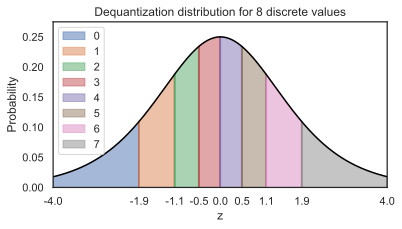

In [18]:
def visualize_dequantization(quants, prior=None):
    """
    Visualize how dequantization spreads discrete values into continuous space.
    """
    # If no categorical prior is given, assume uniform prior
    if prior is None:
        prior = np.ones(quants, dtype=np.float32) / quants
    prior = prior / prior.sum()

    # Create evenly spaced continuous values (real line after inverse sigmoid)
    inp = torch.arange(-4, 4, 0.01).view(-1, 1, 1, 1)
    ldj = torch.zeros(inp.shape[0])
    dequant_module = Dequantization(quants=quants)

    # Apply inverse dequantization (find which discrete bin each z belongs to)
    out, ldj = dequant_module.forward(inp, ldj, reverse=True)

    inp, out, prob = inp.squeeze().numpy(), out.squeeze().numpy(), ldj.exp().numpy()
    prob = prob * prior[out]

    # Plotting
    sns.set_style("white")
    fig = plt.figure(figsize=(6,3))
    x_ticks = []
    for v in np.unique(out):
        indices = np.where(out==v)
        color = to_rgb(f"C{v}")
        plt.fill_between(inp[indices], prob[indices], np.zeros(indices[0].shape[0]), color=color+(0.5,), label=str(v))
        plt.plot([inp[indices[0][0]]]*2,  [0, prob[indices[0][0]]],  color=color)
        plt.plot([inp[indices[0][-1]]]*2, [0, prob[indices[0][-1]]], color=color)
        x_ticks.append(inp[indices[0][0]])
    x_ticks.append(inp.max())
    plt.xticks(x_ticks, [f"{x:.1f}" for x in x_ticks])
    plt.plot(inp,prob, color=(0.0,0.0,0.0))

    plt.ylim(0, prob.max()*1.1)
    plt.xlim(inp.min(), inp.max())
    plt.xlabel("z")
    plt.ylabel("Probability")
    plt.title(f"Dequantization distribution for {quants} discrete values")
    plt.legend()
    plt.show()
    plt.close()

# Show visualization for 8 discrete values
visualize_dequantization(quants=8)

## Dequantization as a lower bound: connection to ELBO

Although normalizing flows allow exact likelihood computation for continuous data, adding dequantization noise turns the problem into estimating:

$$
\log p(x) = \log \mathbb{E}_{u \sim q(u|x)} \left[ \frac{p(x+u)}{q(u|x)} \right]
$$

Unfortunately, this expectation is intractable for discrete data — so during training we approximate it via a **lower bound** using Jensen's inequality:

$$
\log p(x) \geq \mathbb{E}_{u}\left[\log \frac{p(x+u)}{q(u|x)} \right]
$$

- This bound is similar in spirit to the ELBO used in VAEs.
- It becomes tighter if we use more samples $M$ via **importance sampling**:

$$
\log p(x) \geq \mathbb{E}_{u}\left[\log \frac{1}{M} \sum_{m=1}^{M} \frac{p(x+u_m)}{q(u_m|x)} \right]
$$

- In the limit $M \to \infty$, this bound converges to the true likelihood.
- During training, we usually stick to one sample for efficiency.
- During testing, we can afford multiple samples to obtain better likelihood estimates (this is already implemented in `test_step` of our `ImageFlow` class).

This completes the full motivation behind our dequantization module — it is not just a technical fix, but an integral part of applying normalizing flows to discrete data.

## Variational Dequantization

In standard dequantization, we added uniform noise $u \sim U(0, 1)$ to convert discrete integers into continuous data.

However, uniform noise may not be the best choice:

- In real-world images, pixel noise is rarely uniform.
- Sensors typically introduce **Gaussian-like noise** instead.
- Natural data usually clusters around certain values (e.g., pixel intensities are more often mid-gray than very black or very white).

Thus, uniform dequantization leads to "hypercube-shaped" regions with **sharp borders** that are difficult for normalizing flows to model (remember: flows are smooth transformations!).

---

### A better solution: Learn $q(u|x)$

Instead of fixing $q(u|x)$ to be uniform, we can make it **learnable**.

- We train a second normalizing flow to model the dequantization noise conditioned on each image $x$.
- This gives the flow extra flexibility to adapt its dequantization to the true data distribution.
- The learning objective stays the same:
$$
\log p(x) = \log \mathbb{E}_{u \sim q(u|x)} \left[ \frac{p(x+u)}{q(u|x)} \right]
$$
- But now, both $p(x+u)$ and $q(u|x)$ are neural networks!

---

### Visualization

Let’s see why uniform dequantization can be suboptimal:

- In the example below, the prior over discrete values is no longer uniform. Some values (e.g., 2) occur much more frequently than others.
- As a result, the continuous volumes for different discrete values become very uneven.


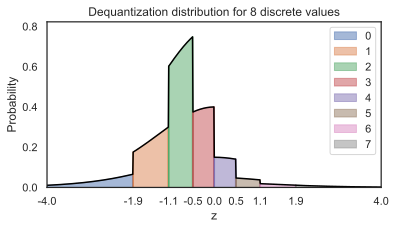

In [19]:
visualize_dequantization(quants=8, prior=np.array([0.075, 0.2, 0.4, 0.2, 0.075, 0.025, 0.0125, 0.0125]))


> You can see that dequantization must now assign much more probability mass to some bins than others.  
> This is hard for standard flows to handle — hence the motivation for **variational dequantization**.

---

### The key idea

We let the model learn its own dequantization noise distribution $q_\theta(u|x)$ using a small flow conditioned on the input image $x$.  
The only constraint is that $u$ stays within $[0, 1)$, which we enforce via a sigmoid transformation.

This approach is called **Variational Dequantization** (Ho et al., 2019), and can significantly improve performance.

### Why is Variational Dequantization needed?

Transforming a complex discrete distribution (like natural images) into a Gaussian through only uniform dequantization is very difficult for the flow:

- The "hard borders" introduced by uniform noise lead to sharp edges in latent space.
- Flows struggle to map these into a smooth Gaussian distribution.

Instead of using fixed uniform noise, we can **learn** a better dequantization distribution. 

We recall the dequantization likelihood objective:

$$
\log p(x) = \log \mathbb{E}_{u \sim q(u|x)} \left[ \frac{p(x+u)}{q(u|x)} \right]
$$

Normally, we fix $q(u|x)$ to be uniform. But we can replace it with a **learned distribution** $q_\theta(u|x)$ that depends on the image $x$.

#### How do we model $q_\theta(u|x)$?

- We introduce a second normalizing flow, dedicated to modeling the dequantization noise.
- This auxiliary flow takes $x$ as input and outputs flexible noise $u$.
- To ensure $u$ stays inside $[0,1)^D$, we apply a **sigmoid activation** at the final stage of this variational dequantization flow.

This method — called **Variational Dequantization** — was proposed by Ho et al. (2019) and leads to much better data adaptation in practice.

In [20]:
class VariationalDequantization(Dequantization):
    """
    Variational Dequantization Layer:
    Instead of uniform noise, we use a learned dequantization distribution q(u|x) modeled by a small conditional flow.
    """

    def __init__(self, var_flows, alpha=1e-5):
        """
        Inputs:
            var_flows - list of flow transformations modeling q(u|x)
            alpha - small constant to avoid boundaries when applying inverse sigmoid
        """
        super().__init__(alpha=alpha)
        self.flows = nn.ModuleList(var_flows)

    def dequant(self, z, ldj):
        """
        Perform dequantization using a learned variational posterior q(u|x)
        """
        z = z.to(torch.float32)

        # Normalize input image x into [-1, 1] for conditioning flows
        img = (z / 255.0) * 2 - 1

        # Initialize dequantization noise u ~ Uniform(0,1)
        deq_noise = torch.rand_like(z).detach()

        # Apply inverse sigmoid to map to full real range
        deq_noise, ldj = self.sigmoid(deq_noise, ldj, reverse=True)

        # Apply learned variational flow to u (conditioned on image x)
        for flow in self.flows:
            deq_noise, ldj = flow(deq_noise, ldj, reverse=False, orig_img=img)

        # Apply sigmoid back to restrict u into [0,1]
        deq_noise, ldj = self.sigmoid(deq_noise, ldj, reverse=False)

        # Apply dequantization noise to original integer z
        z = (z + deq_noise) / 256.0

        # Update log-determinant Jacobian (change of volume)
        ldj -= np.log(256.0) * np.prod(z.shape[1:])

        return z, ldj

### Summary

- Variational dequantization learns a **data-dependent** noise distribution rather than assuming uniform noise.
- We introduce extra flow layers that are conditioned on the original image $x$.
- This allows the overall flow model to handle data distributions much more efficiently.

In practice, variational dequantization often leads to significantly improved likelihoods.

## Coupling Layers: The Core Ingredient

Once we have handled dequantization, we now focus on the heart of normalizing flows: **how to transform data step by step into a Gaussian distribution.**

The challenge:
- We need invertible transformations that are flexible enough to model complex distributions.
- At the same time, we need to efficiently compute their Jacobian determinant, as this enters directly into the likelihood.

---

### The Coupling Layer: An Elegant Trade-off

The **coupling layer** (introduced by Dinh et al., 2016) solves both problems:

- It splits the input variables $z$ into two parts:
  - The first half $z_{1:j}$ remains unchanged.
  - The second half $z_{j+1:d}$ is transformed *conditionally* on $z_{1:j}$.
  
- The transformation applied to $z_{j+1:d}$ is **affine**:
  
$$
z'_{j+1:d} = \mu_\theta(z_{1:j}) + \sigma_\theta(z_{1:j}) \odot z_{j+1:d}
$$

where:
- $\mu_\theta$ and $\sigma_\theta$ are neural networks.
- $\odot$ means elementwise multiplication.
- $z_{1:j}$ controls how $z_{j+1:d}$ is transformed.

---

### Why splitting works

- The first part $z_{1:j}$ stays fixed and acts like a "context" or "conditioning" for transforming the second part.
- This guarantees invertibility: we can easily recover $z_{j+1:d}$ via:

$$
z_{j+1:d} = \frac{z'_{j+1:d} - \mu_\theta(z_{1:j})}{\sigma_\theta(z_{1:j})}
$$

- The Jacobian is triangular (upper or lower), so the log-determinant simplifies to:

$$
\log \det J = \sum_i \log \sigma_\theta(z_{1:j})_i
$$

which is very cheap to compute!

---

### Visual intuition

The following diagram shows clearly how information flows through the coupling layer in both forward and inverse passes:

<center width="100%"><img src="https://raw.githubusercontent.com/Lightning-AI/tutorials/main/course_UvA-DL/09-normalizing-flows/coupling_flow.svg" width="450px"></center>

- On the **left**: forward transformation (sampling, density estimation).
- On the **right**: inverse transformation (generation).

---

### Summary

Coupling layers allow:
- Easy invertibility
- Cheap log-determinant computation
- Flexibility by using neural networks to parameterize the transformation

We will now implement them step-by-step.

In [ ]:
class CouplingLayer(nn.Module):
    """
    Affine Coupling Layer for Normalizing Flows.
    
    Applies an invertible transformation where one part of the input remains fixed,
    and the other part is scaled+shifted conditioned on the fixed part.
    """

    def __init__(self, network, mask, c_in):
        """
        Inputs:
            network - Neural network producing both scale and shift parameters (2*c_in channels)
            mask - Binary mask indicating which variables to transform
            c_in - Number of input channels
        """
        super().__init__()
        self.network = network
        
        # Learnable parameter to stabilize scaling output
        self.scaling_factor = nn.Parameter(torch.zeros(c_in))
        
        # Register mask as buffer (non-trainable parameter saved in model state)
        self.register_buffer('mask', mask)

    def forward(self, z, ldj, reverse=False, orig_img=None):
        """
        Inputs:
            z - Input tensor
            ldj - Log-determinant Jacobian (accumulated so far)
            reverse - Whether to apply forward or inverse transformation
            orig_img - Optional input used for conditioning in variational dequantization
        """
        # Apply mask: select only part of z to input into NN
        z_in = z * self.mask

        # Forward pass through NN, optionally conditioned on image
        if orig_img is None:
            nn_out = self.network(z_in)
        else:
            nn_out = self.network(torch.cat([z_in, orig_img], dim=1))

        # Split network output into scale (s) and translation (t)
        s, t = nn_out.chunk(2, dim=1)

        # Stabilize scaling output using learned factor
        s_fac = self.scaling_factor.exp().view(1, -1, 1, 1) # exp(s) guarantees that the scaling factor is always positive, which guarantees invertibility and gives an easy Jacobian
        s = torch.tanh(s / s_fac) * s_fac

        # Only apply transformations to unmasked variables
        s = s * (1 - self.mask)
        t = t * (1 - self.mask)

        # Apply affine transformation (either forward or inverse)
        if not reverse:
            z = (z + t) * torch.exp(s)
            ldj += s.sum(dim=[1,2,3])
        else:
            z = (z * torch.exp(-s)) - t
            ldj -= s.sum(dim=[1,2,3])

        return z, ldj

## Stabilizing the Scaling Output

Coupling layers apply an **affine transformation** where one part of the variables is scaled and shifted:

$$
z' = \sigma(z_{\text{context}}) \cdot z + \mu(z_{\text{context}})
$$

However, there's one problem:  
If the output of $\sigma(\cdot)$ becomes very large or very small during training, this may:

- Cause numerical instability.
- Blow up gradients.
- Lead to divergence of the log-likelihood (since $\log \det J$ depends on $\log \sigma$).

---

### Solution: Bounding the scaling output

To stabilize training, we:

1. Apply a $\tanh(\cdot)$ function to the scale outputs:
    - This naturally keeps values inside $(-1, 1)$.

2. Allow flexibility by introducing a **learnable scaling factor** per dimension:
    - We multiply $\tanh(\cdot)$ by a positive learnable parameter.
    - This lets the model adapt the effective range of scaling per dimension.

Mathematically:

$$
s = \tanh\left( \frac{\hat{s}}{\text{scale}} \right) \cdot \text{scale}
$$

where:
- $\hat{s}$ is the raw output of the network.
- $\text{scale}$ is the learned scaling factor (`scaling_factor.exp()` in code).

---

### Visualizing the effect

The plot below in the next cell shows how the scaling factor changes the range and smoothness of the scaled $\tanh(\cdot)$ function:

- For small scaling factors (left panel), the output saturates very quickly.
- For large scaling factors (right panel), the curve becomes almost linear over a wider input range.
- The learnable scaling allows the flow to adapt its flexibility depending on the data.

This simple trick helps stabilize flow training while keeping enough modeling power.

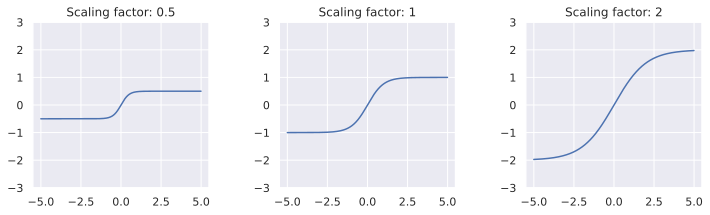

In [22]:
with torch.no_grad():
    x = torch.arange(-5, 5, 0.01)
    scaling_factors = [0.5, 1, 2]

    sns.set()
    fig, ax = plt.subplots(1, 3, figsize=(12, 3))
    for i, scale in enumerate(scaling_factors):
        y = torch.tanh(x / scale) * scale
        ax[i].plot(x.numpy(), y.numpy())
        ax[i].set_title("Scaling factor: " + str(scale))
        ax[i].set_ylim(-3, 3)
    plt.subplots_adjust(wspace=0.4)
    sns.reset_orig()
    plt.show()

## Masking Strategies for Images

In the previous section, we introduced coupling layers that transform part of the variables while leaving the rest fixed.

For images, the question is: **how do we split the image variables?**

We usually want:

- Every pixel to eventually be transformed.
- A design that makes use of the spatial structure of images.

Two popular masking strategies are used:

---

### 1️⃣ Checkerboard Mask

- Splits pixels like a chess board: alternate black and white pixels.
- Applied identically across channels.
- Allows spatial mixing between nearby pixels.
- Especially useful for early flow layers.

### 2️⃣ Channel Mask

- Splits along channels: first half channels are conditioned variables, second half are transformed.
- Common after downsampling or squeezing layers, where channels increase.


In [23]:
def create_checkerboard_mask(h, w, invert=False):
    """
    Create a checkerboard mask of shape (1, 1, h, w)
    """
    x, y = torch.arange(h, dtype=torch.int32), torch.arange(w, dtype=torch.int32)
    xx, yy = torch.meshgrid(x, y, indexing='ij')
    mask = torch.fmod(xx + yy, 2)  # alternating 0/1 across spatial dimensions
    mask = mask.to(torch.float32).view(1, 1, h, w)
    if invert:
        mask = 1 - mask
    return mask

def create_channel_mask(c_in, invert=False):
    """
    Create a channel-wise mask of shape (1, c_in, 1, 1)
    """
    mask = torch.cat([
        torch.ones(c_in // 2, dtype=torch.float32),
        torch.zeros(c_in - c_in // 2, dtype=torch.float32)
    ])
    mask = mask.view(1, c_in, 1, 1)
    if invert:
        mask = 1 - mask
    return mask

## Visualizing the Masks

Let's visualize what these masks look like for an image of shape $8 \times 8 \times 2$:

- Checkerboard splits the pixels spatially.
- Channel mask splits between channels.

By alternating these masks across coupling layers, we ensure that all variables are eventually transformed multiple times.

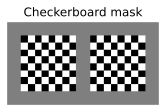

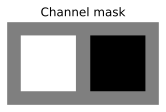

In [24]:
checkerboard_mask = create_checkerboard_mask(h=8, w=8).expand(-1,2,-1,-1)
channel_mask = create_channel_mask(c_in=2).expand(-1,-1,8,8)

show_imgs(checkerboard_mask.transpose(0,1), "Checkerboard mask")
show_imgs(channel_mask.transpose(0,1), "Channel mask")

### Interpreting the Visualization

- In the **checkerboard mask** (top):
  - White squares (value 1): these are the fixed variables.
  - Black squares (value 0): these will be transformed by the coupling layer.

- In the **channel mask** (bottom):
  - First channel: all white (value 1) → fixed.
  - Second channel: all black (value 0) → transformed.

By alternating both masks across layers, we ensure that every variable participates as both context and transformed part across the flow.

## Designing the Neural Network for the Coupling Layers

In the coupling layer, we need to predict:

- The shift $\mu(z_{1:j})$  
- The scale $\sigma(z_{1:j})$

To compute these two terms, we pass $z_{1:j}$ through a neural network.

---

### Why not just use a simple CNN?

- Images have strong spatial structure → CNNs are ideal.
- However, normal CNNs might suffer from:
  - Vanishing gradients (especially with many coupling layers stacked).
  - Poor long-range dependencies.

---

### Solution: Gated Residual Networks (Gated ResNet)

We use **Gated ResNets** for their:

- Stable gradient flow.
- High capacity to model complex transformations.
- Proven success in advanced flow models (e.g. Flow++).

---

### Key ingredients:

- **Residual connection** → direct path from input to output.
- **Gating mechanism** → learns how much of residual to add.
- **LayerNorm over channels** → stabilizes feature statistics.
- **ConcatELU** → improved non-linearity that avoids dead neurons.

---

This architecture gives our coupling layers both **stability** and **flexibility** when learning complex image distributions.

In [25]:
class ConcatELU(nn.Module):
    """
    Activation function: applies ELU both to x and -x.
    Helps maintain strong gradients for all input values.
    """
    def forward(self, x):
        return torch.cat([F.elu(x), F.elu(-x)], dim=1)


class LayerNormChannels(nn.Module):
    """
    Applies layer normalization across channels.
    Each spatial position is normalized across channels.
    """
    def __init__(self, c_in, eps=1e-5):
        super().__init__()
        self.gamma = nn.Parameter(torch.ones(1, c_in, 1, 1))
        self.beta = nn.Parameter(torch.zeros(1, c_in, 1, 1))
        self.eps = eps

    def forward(self, x):
        mean = x.mean(dim=1, keepdim=True)
        var = x.var(dim=1, unbiased=False, keepdim=True)
        y = (x - mean) / torch.sqrt(var + self.eps)
        return y * self.gamma + self.beta


class GatedConv(nn.Module):
    """
    Core Gated ResNet block: 2-layer CNN with gating mechanism.
    """
    def __init__(self, c_in, c_hidden):
        super().__init__()
        self.net = nn.Sequential(
            ConcatELU(),
            nn.Conv2d(2 * c_in, c_hidden, kernel_size=3, padding=1),
            ConcatELU(),
            nn.Conv2d(2 * c_hidden, 2 * c_in, kernel_size=1)
        )

    def forward(self, x):
        out = self.net(x)
        val, gate = out.chunk(2, dim=1)
        return x + val * torch.sigmoid(gate)


class GatedConvNet(nn.Module):
    """
    Full coupling layer network combining multiple GatedConv blocks.
    Outputs both mu and sigma for affine transformation.
    """
    def __init__(self, c_in, c_hidden=32, c_out=-1, num_layers=3):
        super().__init__()
        c_out = c_out if c_out > 0 else 2 * c_in  # output = mu and sigma

        layers = [nn.Conv2d(c_in, c_hidden, kernel_size=3, padding=1)]
        for _ in range(num_layers):
            layers += [GatedConv(c_hidden, c_hidden), LayerNormChannels(c_hidden)]

        layers += [
            ConcatELU(),
            nn.Conv2d(2 * c_hidden, c_out, kernel_size=3, padding=1)
        ]
        self.nn = nn.Sequential(*layers)

        # Output layer initialized to zero: model starts as identity transform
        nn.init.zeros_(self.nn[-1].weight)
        nn.init.zeros_(self.nn[-1].bias)

    def forward(self, x):
        return self.nn(x)

### Putting It All Together: Our Flow Model

Now that we have:

- Dequantization (both regular and variational),
- Coupling layers (with Gated CNNs),
- Checkerboard masking,

...we are finally ready to build the full normalizing flow for image modeling!

---

### Model Architecture Recap

Our architecture consists of two main components:

1️⃣ **Dequantization Block**  
- Either standard Dequantization or Variational Dequantization (more flexible).
- If Variational Dequantization is enabled:  
    - We stack 4 coupling layers inside the variational flow.

2️⃣ **Main Flow Block**  
- 8 Coupling Layers operating on the full image.
- Each coupling layer uses a Gated CNN to predict scale and shift.
- We use a **checkerboard mask** since MNIST has only 1 channel.

---

The overall flow diagram looks like this:

<center width="100%" style="padding: 20px"><img src="https://github.com/phlippe/uvadlc_notebooks/blob/master/docs/tutorial_notebooks/tutorial11/vanilla_flow.svg?raw=1" width="900px"></center>

**Key insight:**  
Every coupling layer incrementally reshapes the simple Gaussian prior into the complex MNIST distribution, one transformation at a time.

In [26]:
def create_simple_flow(use_vardeq=True):
    flow_layers = []

    # --- Step 1: Dequantization ---
    if use_vardeq:
        # Build variational dequantization (4 internal coupling layers)
        vardeq_layers = [
            CouplingLayer(
                network=GatedConvNet(c_in=2, c_out=2, c_hidden=16),
                mask=create_checkerboard_mask(h=28, w=28, invert=(i % 2 == 1)),
                c_in=1
            )
            for i in range(4)
        ]
        flow_layers += [VariationalDequantization(var_flows=vardeq_layers)]
    else:
        # Use simple uniform dequantization
        flow_layers += [Dequantization()]

    # --- Step 2: Main Flow Coupling Layers ---
    for i in range(8):
        flow_layers += [
            CouplingLayer(
                network=GatedConvNet(c_in=1, c_hidden=32),
                mask=create_checkerboard_mask(h=28, w=28, invert=(i % 2 == 1)),
                c_in=1
            )
        ]

    # Wrap everything into our final ImageFlow model
    flow_model = ImageFlow(flow_layers).to(device)
    return flow_model

### Time to Train our Flow!

Now that we have fully defined the architecture, we can move on to training the model. Since normalizing flows can be quite complex, we'll leverage **PyTorch Lightning** to simplify:

- Less boilerplate code.
- Easier logging, checkpointing, and multi-device support.
- Clean separation between model definition and training logic.

### Small caveat:

Normalizing flows can take **a long time to train** due to:
- Multiple invertible transformations.
- Expensive importance sampling during evaluation.
- High-dimensional inputs.

Therefore, in this notebook we will:
- Provide **pre-trained models** you can load automatically.
- Still show you the full training code in case you want to train from scratch.

---

In [27]:
def train_flow(flow, model_name="MNISTFlow"):
    """
    This function handles the full training loop for our normalizing flow model.

    Arguments:
        flow: The ImageFlow model we want to train.
        model_name: Used for checkpoint storage and loading.

    Returns:
        Trained flow model, and test results (bits per dimension).
    """
    # Lightning Trainer Setup
    trainer = pl.Trainer(
        default_root_dir=os.path.join(CHECKPOINT_PATH, model_name),
        accelerator="gpu" if str(device).startswith("cuda") else "cpu",
        devices=1,
        max_epochs=200,
        gradient_clip_val=1.0,  # prevents exploding gradients
        callbacks=[
            ModelCheckpoint(save_weights_only=True, mode="min", monitor="val_bpd"),
            LearningRateMonitor("epoch")
        ],
        check_val_every_n_epoch=5
    )
    trainer.logger._log_graph = True
    trainer.logger._default_hp_metric = None  # we skip HP logging for simplicity

    # Create data loader for training set
    train_data_loader = data.DataLoader(
        train_set, batch_size=128, shuffle=True,
        drop_last=True, pin_memory=True, num_workers=8
    )

    result = None

    # If pretrained model exists, load it (to save time)
    pretrained_filename = os.path.join(CHECKPOINT_PATH, model_name + ".ckpt")
    if os.path.isfile(pretrained_filename):
        print("Found pretrained model, loading...")
        ckpt = torch.load(pretrained_filename, map_location=device)
        flow.load_state_dict(ckpt['state_dict'])
        result = ckpt.get("result", None)
    else:
        print("Start training", model_name)
        trainer.fit(flow, train_data_loader, val_loader)

    # Evaluate both on validation and test set (importance sampling involved)
    if result is None:
        val_result = trainer.test(flow, val_loader, verbose=False)
        start_time = time.time()
        test_result = trainer.test(flow, test_loader, verbose=False)
        duration = time.time() - start_time
        result = {
            "test": test_result,
            "val": val_result,
            "time": duration / len(test_loader) / flow.import_samples
        }

    return flow, result

### Multi-Scale Flows

A core limitation of normalizing flows is that they require the latent space to have the exact same dimensionality as the input data. This means:

- For high-dimensional data (like images), flows need to transform **all pixels individually**.
- The higher the dimensionality, the more difficult the optimization becomes.
- Many pixels in images contain very little *semantically meaningful* information (background pixels, redundant regions, etc.).

Hence, we introduce **multi-scale flows** to progressively:
- Compress information from spatial dimensions into channel dimensions.
- Allow the network to focus on the "important" content as we go deeper.
- Reduce computation cost and memory consumption as we downscale.

---

### The key operations:
- **Squeeze:** Rearranges pixels into channels (without losing information).
- **Split:** After squeezing, drop (or route directly to prior) part of the representation.

The squeezing operation groups local pixel neighborhoods (e.g., 2×2 patches) and stacks them as channels:

$$
\text{squeeze}: \mathbb{R}^{H \times W \times C} \quad \longrightarrow \quad \mathbb{R}^{(H/2) \times (W/2) \times (4C)}
$$

This way, spatial context is transformed into channel-wise context.

---

### Intuition via visualization:

<center><img src="https://github.com/phlippe/uvadlc_notebooks/blob/master/docs/tutorial_notebooks/tutorial11/Squeeze_operation.svg?raw=1" width="40%"/></center>

- A $4 \times 4 \times 1$ image becomes $2 \times 2 \times 4$ after squeeze.
- We still preserve all pixel values, but reorganized.
- Later, we can split some channels and directly map them to the latent space.

---

This progressively reduces the burden for deeper flow layers, allowing better modeling and faster convergence.

In [28]:
class SqueezeFlow(nn.Module):
    """
    Implements the invertible Squeeze operation used in multi-scale flows.

    The operation rearranges spatial pixels into channels:
      - Forward: (B, C, H, W) -> (B, 4C, H/2, W/2)
      - Reverse: (B, 4C, H/2, W/2) -> (B, C, H, W)

    Note: Fully invertible! No information is lost.
    """
    
    def forward(self, z, ldj, reverse=False):
        B, C, H, W = z.shape
        
        if not reverse:
            # Forward direction: Squeeze
            # 1. Reshape into 2x2 patches
            z = z.reshape(B, C, H//2, 2, W//2, 2)
            # 2. Rearrange axes: bring patch pixels into channels
            z = z.permute(0, 1, 3, 5, 2, 4)
            # 3. Flatten patches into channels
            z = z.reshape(B, 4*C, H//2, W//2)
        else:
            # Reverse direction: Unsqueeze
            z = z.reshape(B, C//4, 2, 2, H, W)
            z = z.permute(0, 1, 4, 2, 5, 3)
            z = z.reshape(B, C//4, H*2, W*2)
        
        return z, ldj  # Note: No change to ldj (volume-preserving)

Before proceeding, it's always a good practice to verify that our flow operations are indeed invertible, as invertibility is at the core of normalizing flows. Here, we will apply our `SqueezeFlow` implementation on a simple toy tensor and check whether applying forward and reverse operations leads back to the original tensor.

In [29]:
# Instantiate squeeze layer
sq_flow = SqueezeFlow()

# Create a simple toy image with values 1 to 16 in a 4x4 spatial grid
rand_img = torch.arange(1, 17).view(1, 1, 4, 4)

# Print original image tensor
print("Image (before)\n", rand_img)

# Apply Squeeze operation (forward direction)
forward_img, _ = sq_flow(rand_img, ldj=None, reverse=False)

# Print squeezed image (for better readability we permute dimensions to [B,H,W,C])
print("\nImage (forward)\n", forward_img.permute(0,2,3,1))

# Apply inverse (unsqueeze)
reconst_img, _ = sq_flow(forward_img, ldj=None, reverse=True)

# Verify whether we recover the original image
print("\nImage (reverse)\n", reconst_img)

Image (before)
 tensor([[[[ 1,  2,  3,  4],
          [ 5,  6,  7,  8],
          [ 9, 10, 11, 12],
          [13, 14, 15, 16]]]])

Image (forward)
 tensor([[[[ 1,  2,  5,  6],
          [ 3,  4,  7,  8]],

         [[ 9, 10, 13, 14],
          [11, 12, 15, 16]]]])

Image (reverse)
 tensor([[[[ 1,  2,  3,  4],
          [ 5,  6,  7,  8],
          [ 9, 10, 11, 12],
          [13, 14, 15, 16]]]])


If implemented correctly, the original tensor and the reconstructed tensor after applying forward and reverse should match exactly.

The output of this test will show:

- The input tensor (1×1×4×4).
- The squeezed tensor (1×4×2×2), rearranged as channels.
- The recovered tensor (1×1×4×4), which should exactly match the input.

By running this, we confirm that:

- The squeezing operation correctly rearranges spatial locations into channels.
- The operation is perfectly invertible (as any flow transformation must be).


## Split Layer

After squeezing the image (which reduced its spatial size but increased the number of channels), we apply the **Split operation**.

### Why do we need splitting?

- **Dimensionality reduction:**  
  Instead of transforming all latent variables through every layer, we progressively split off parts of the latent space that are "ready", i.e., already well modeled.
  
- **Efficiency:**  
  By reducing the dimensionality at every stage, the computation for later flow layers becomes cheaper.
  
- **Progressive refinement:**  
  Early layers handle global structure, while later layers focus on finer details.

---

### What does the split do?

- After some transformations, we split $z$ into two halves:  
  - One half continues through the flow.
  - The other half is immediately evaluated under the **prior distribution** (standard normal).
  
- Instead of delaying prior evaluation until the end, we incorporate the contribution of each split directly into the **log-determinant Jacobian (LDJ)** during training:

$$
\text{LDJ} \leftarrow \text{LDJ} + \log p(z_{\text{split}})
$$

---

### Summary

- In **forward mode** (during training):  
  - Split half of channels.  
  - Compute log-probability of the split-off part and add to LDJ.
  
- In **reverse mode** (during sampling):  
  - Sample new values for the split-off part from the prior.  
  - Concatenate them back into the latent vector to reconstruct full $z$.

In [30]:
class SplitFlow(nn.Module):

    def __init__(self):
        super().__init__()
        # We always assume a standard Normal prior for the split variables
        self.prior = torch.distributions.normal.Normal(loc=0.0, scale=1.0)

    def forward(self, z, ldj, reverse=False):
        if not reverse:
            # Forward: split z into two parts along the channel dimension
            z, z_split = z.chunk(2, dim=1)
            # Add log-probability of split-off variables to ldj
            ldj += self.prior.log_prob(z_split).sum(dim=[1, 2, 3])
        else:
            # Reverse: sample new variables from the prior and concatenate
            z_split = self.prior.sample(sample_shape=z.shape).to(device)
            z = torch.cat([z, z_split], dim=1)
            # Subtract log-probability of sampled variables from ldj (inversion)
            ldj -= self.prior.log_prob(z_split).sum(dim=[1, 2, 3])
        return z, ldj

## Building a Multi-Scale Flow

---

### The challenge with high-dimensional inputs

- Normalizing flows process data with the **same dimensionality** as the input.
- For images like MNIST (28x28 pixels), this means the flow works directly on 784 latent variables.
- However, many pixels contain **redundant information** (e.g. backgrounds, smooth regions, empty space).
- **Multi-scale flows** allow us to progressively reduce dimensionality while still preserving relevant information.

---

### The multi-scale idea

- After a few coupling layers, we:
  1. **Squeeze**:  
     Reduce spatial size while increasing channels (more efficient computation).
  2. **Split**:  
     Send part of the latent variables directly to the prior.
  3. Continue transforming remaining variables with more coupling layers.
  
- This allows:
  - Early layers to model global structure.
  - Deeper layers to focus on local details.

---

### Architecture for MNIST

For this notebook, we use a design inspired by **RealNVP**:

- **Dequantization**  
  - First, apply (Variational) Dequantization.

- **Coupling layers (before squeezing)**  
  - Apply 2 coupling layers with checkerboard masking.

- **First squeeze**  
  - Transform $28 \times 28 \times 1$ into $14 \times 14 \times 4$.

- **Coupling layers (after first squeeze)**  
  - Apply 2 coupling layers with channel masking.

- **First split**  
  - Split off half the channels.

- **Second squeeze**  
  - Transform $14 \times 14 \times 2$ into $7 \times 7 \times 8$.

- **Final coupling layers**  
  - Apply 4 more coupling layers.

---

### Visualization of the architecture

We can summarize the full architecture visually:

<center><img src="https://github.com/phlippe/uvadlc_notebooks/blob/master/docs/tutorial_notebooks/tutorial11/multiscale_flow.svg?raw=1" width="1000px"></center>

---

### Why increase hidden dimensions?

- After squeezing, we have more channels but smaller spatial resolution.
- To balance the **modeling capacity**, we increase hidden size for later coupling layers:
  - Hidden sizes: 32 → 48 → 64.
  - This allows us to model finer details at each stage.

---

In [31]:
# ------------------------------------------------------
# Function to build the full multi-scale normalizing flow
# ------------------------------------------------------

def create_multiscale_flow():
    flow_layers = []

    # ------------------------------------------------------
    # STEP 1: Variational Dequantization
    # ------------------------------------------------------
    vardeq_layers = [
        CouplingLayer(
            network=GatedConvNet(c_in=2, c_out=2, c_hidden=16),
            mask=create_checkerboard_mask(h=28, w=28, invert=(i % 2 == 1)),
            c_in=1
        ) 
        for i in range(4)
    ]
    flow_layers.append(VariationalDequantization(vardeq_layers))

    # ------------------------------------------------------
    # STEP 2: First set of coupling layers (before squeeze)
    # ------------------------------------------------------
    flow_layers += [
        CouplingLayer(
            network=GatedConvNet(c_in=1, c_hidden=32),
            mask=create_checkerboard_mask(h=28, w=28, invert=(i % 2 == 1)),
            c_in=1
        ) 
        for i in range(2)
    ]

    # ------------------------------------------------------
    # STEP 3: First squeeze operation (28x28x1 → 14x14x4)
    # ------------------------------------------------------
    flow_layers.append(SqueezeFlow())

    # ------------------------------------------------------
    # STEP 4: Second set of coupling layers (after squeeze)
    # ------------------------------------------------------
    flow_layers += [
        CouplingLayer(
            network=GatedConvNet(c_in=4, c_hidden=48),
            mask=create_channel_mask(c_in=4, invert=(i % 2 == 1)),
            c_in=4
        ) 
        for i in range(2)
    ]

    # ------------------------------------------------------
    # STEP 5: First split (remove half of the channels)
    # ------------------------------------------------------
    flow_layers.append(SplitFlow())

    # ------------------------------------------------------
    # STEP 6: Second squeeze operation (14x14x2 → 7x7x8)
    # ------------------------------------------------------
    flow_layers.append(SqueezeFlow())

    # ------------------------------------------------------
    # STEP 7: Final coupling layers (after second squeeze)
    # ------------------------------------------------------
    flow_layers += [
        CouplingLayer(
            network=GatedConvNet(c_in=8, c_hidden=64),
            mask=create_channel_mask(c_in=8, invert=(i % 2 == 1)),
            c_in=8
        ) 
        for i in range(4)
    ]

    # ------------------------------------------------------
    # Create full flow model
    # ------------------------------------------------------
    flow_model = ImageFlow(flow_layers).to(device)
    
    return flow_model

### Comparing number of parameters

Before we move forward, it’s useful to compare how many trainable parameters each architecture has. This will help us understand the model capacity and give some intuition about the computational complexity involved. Below, we compute the total number of parameters for:

- A simple flow without variational dequantization.
- A simple flow with variational dequantization.
- The full multi-scale flow architecture.

In [32]:
# ------------------------------------------------------
# Function to compute total number of trainable parameters
# ------------------------------------------------------
def print_num_params(model):
    num_params = sum([np.prod(p.shape) for p in model.parameters()])
    print("Number of parameters: {:,}".format(num_params))


# ------------------------------------------------------
# Compare single-scale flow (without variational dequantization)
# ------------------------------------------------------
print("Simple flow without variational dequantization:")
print_num_params(create_simple_flow(use_vardeq=False))

# ------------------------------------------------------
# Compare single-scale flow (with variational dequantization)
# ------------------------------------------------------
print("\nSimple flow with variational dequantization:")
print_num_params(create_simple_flow(use_vardeq=True))

# ------------------------------------------------------
# Compare multi-scale flow
# ------------------------------------------------------
print("\nMulti-scale flow:")
print_num_params(create_multiscale_flow())

Simple flow without variational dequantization:
Number of parameters: 556,312

Simple flow with variational dequantization:
Number of parameters: 628,388

Multi-scale flow:
Number of parameters: 1,711,818


Although the multi-scale flow has almost 3 times the parameters of the single-scale flow, this does not mean that training or inference will take 3 times longer. Thanks to the use of operations like squeezing and splitting, the model becomes computationally more efficient despite the higher parameter count. We will explore these runtime differences in the next experiments.

## Analyzing the Flow Architectures

In this final part of the notebook, we will compare the performance and efficiency of the three flow architectures we’ve built:

- A **simple flow** without variational dequantization.
- A **simple flow** with variational dequantization.
- A **multi-scale flow** with both variational dequantization and hierarchical structure.

The goal is to understand how each design choice—such as multi-scale decomposition or learning the dequantization distribution—impacts both performance and efficiency.

---

### Training the Flow Variants

Before analyzing, we need to train the models. However, since training normalizing flows is computationally expensive, especially with importance sampling in evaluation, we provide **pre-trained models**. These contain not only learned parameters but also:

- **Validation and test set results**
- **Runtime per evaluation**
- **Bits-per-dimension (BPD)** metrics

> If you're short on time or running this on a CPU, you can rely on the pretrained checkpoints and skip re-training.

Let’s now train—or load—the models for each of the three variants:

In [33]:
# Dictionary to hold all flow models and their results
flow_dict = {
    "simple": {},
    "vardeq": {},
    "multiscale": {}
}

# Train or load simple flow without variational dequantization
flow_dict["simple"]["model"], flow_dict["simple"]["result"] = train_flow(
    create_simple_flow(use_vardeq=False), model_name="MNISTFlow_simple"
)

# Train or load simple flow with variational dequantization
flow_dict["vardeq"]["model"], flow_dict["vardeq"]["result"] = train_flow(
    create_simple_flow(use_vardeq=True), model_name="MNISTFlow_vardeq"
)

# Train or load multi-scale flow
flow_dict["multiscale"]["model"], flow_dict["multiscale"]["result"] = train_flow(
    create_multiscale_flow(), model_name="MNISTFlow_multiscale"
)

GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/opt/homebrew/Caskroom/miniconda/base/lib/python3.12/site-packages/pytorch_lightning/trainer/setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
/var/folders/jp/6dqt28x13gl0mvh7lthhyjxm0002jl/T/ipykernel_71437/1246310227.py:40: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by 

Found pretrained model, loading...
Found pretrained model, loading...
Found pretrained model, loading...


In [34]:
# Display results from simple flow
flow_dict["simple"]["result"]

{'test': [{'test_bpd': 1.07839834690094}],
 'val': [{'test_bpd': 1.0798484086990356}],
 'time': 0.019570968523147,
 'samp_time': 0.017716965675354003}

### Density Modeling and Sampling

Now that we have trained all three flow variants, let’s compare their **quantitative performance** across key metrics:

- **Validation BPD (Bits per dimension):** How well the model fits the validation data.
- **Test BPD:** Same as above, but for unseen data.
- **Inference time:** Time to compute the likelihood of a batch of 64 images.
- **Sampling time:** Time to generate a batch of 64 new images from the model.
- **Number of parameters:** Total trainable parameters in the architecture.

The BPD (bits per dimension) is a commonly used metric in generative modeling that corresponds to the negative log-likelihood scaled by image dimensions and converted to base 2. Lower values indicate better models.

Let’s summarize these statistics in a table:

In [35]:
%%html
<!-- Some HTML code to increase font size in the following table -->
<style>
th {font-size: 120%;}
td {font-size: 120%;}
</style>

In [37]:
import tabulate
from IPython.display import display, HTML

# Construct a summary table with evaluation metrics for each model
table = [
    [
        key,
        "%4.3f bpd" % flow_dict[key]["result"]["val"][0]["test_bpd"],
        "%4.3f bpd" % flow_dict[key]["result"]["test"][0]["test_bpd"],
        "%2.0f ms" % (1000 * flow_dict[key]["result"]["time"]),
        "%2.0f ms" % (1000 * flow_dict[key]["result"].get("samp_time", 0)),
        "{:,}".format(sum([np.prod(p.shape) for p in flow_dict[key]["model"].parameters()]))
    ]
    for key in flow_dict
]

# Display the table nicely in HTML
display(HTML(tabulate.tabulate(
    table,
    tablefmt='html',
    headers=["Model", "Validation BPD", "Test BPD", "Inference Time", "Sampling Time", "Num Parameters"]
)))

Model,Validation BPD,Test BPD,Inference Time,Sampling Time,Num Parameters
simple,1.080 bpd,1.078 bpd,20 ms,18 ms,"556,312"
vardeq,1.045 bpd,1.043 bpd,26 ms,18 ms,"628,388"
multiscale,1.022 bpd,1.020 bpd,23 ms,15 ms,"1,711,818"


### Analyzing Results and Sampling Quality

As anticipated, using **Variational Dequantization** improves the model’s performance compared to standard (uniform) dequantization. Even though the reduction is around **0.04 bits per dimension (BPD)**, this is actually a significant improvement in the context of generative modeling. For reference, many state-of-the-art papers report improvements in the range of **0.02–0.10 BPD**, often requiring major architectural changes or increased model size.

This improvement comes with a trade-off: **longer inference time**. Since the variational dequantization uses a learned transformation, evaluating the log-likelihood is more expensive. However, **sampling remains fast**—similar to the uniform case—because sampling just requires applying the inverse transformation, which is shared between both dequantization schemes.

When we move to the **multi-scale flow**, we observe:
- An additional drop of ~0.02 BPD (better performance),
- **Faster sampling**, despite having significantly more parameters.

This highlights that **multi-scale architectures not only improve performance but also increase efficiency**, due to operating on reduced spatial resolutions.

---

Let’s now look at **samples** from the trained models. We'll visualize outputs from:
- The **variational dequantization** model (`"vardeq"`)
- The **multi-scale** model (`"multiscale"`)

Although we omit visualizing the `"simple"` model for now, you are encouraged to test it on your own. Seeds are fixed for reproducibility.

Seed set to 44


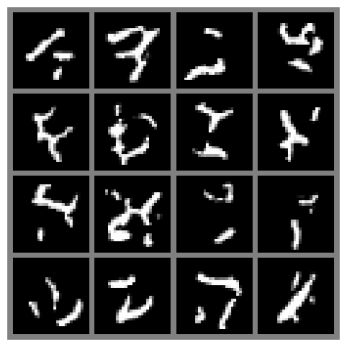

In [38]:
pl.seed_everything(44)
samples = flow_dict["vardeq"]["model"].sample(img_shape=[16,1,28,28])
show_imgs(samples.cpu())

Seed set to 42


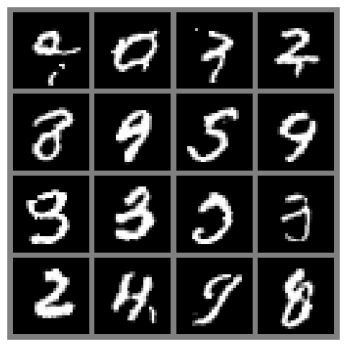

In [39]:
pl.seed_everything(42)
samples = flow_dict["multiscale"]["model"].sample(img_shape=[16,8,7,7])
show_imgs(samples.cpu())

### Sample Quality and Model Comparison

From the generated samples, we can observe a **clear qualitative difference** between the simple and multi-scale models:

- The **single-scale model** (with uniform or variational dequantization) mainly captures **local patterns**—edges or small curves—but often fails to assemble them into coherent, full digits.
- In contrast, the **multi-scale model** successfully learns **global structures**, producing digits that resemble those in the MNIST dataset more consistently.

This highlights one of the major advantages of multi-scale architectures: by compressing spatial information and allowing deeper transformations at different resolutions, they can model complex long-range dependencies more effectively.

Another interesting observation is that, **unlike VAEs**, these samples appear **sharp and clean**. This is because:
- **Normalizing flows** can model complex, multi-modal distributions directly.
- VAEs, on the other hand, often suffer from blurry reconstructions due to their **independent decoder noise assumptions**.

That said, **not all samples are perfect**. Some generated digits may still look ambiguous or unrealistic. This indicates that while the model is strong, there's still room for improvement in capturing the full data distribution.

### Interpolation in Latent Space

One insightful way to evaluate the **structure and smoothness** of the latent space in generative models is through **latent space interpolation**. The idea is simple: take two images, map them to latent space, and linearly interpolate between their latent representations. If the model has learned a meaningful, smooth latent space, the decoded images along the interpolation path should show a gradual transformation from one image to the other.

Normalizing flows have a significant advantage here: due to their **invertibility**, we are guaranteed that every input image has an exact latent representation and vice versa. This ensures interpolations remain within the data manifold.

In the following code, we use this method to compare how well
- the **variational dequantization model** and
- the **multi-scale model**

handle latent interpolation. Each row of the output grid shows how one digit morphs into another across several steps.

In [40]:
@torch.no_grad()
def interpolate(model, img1, img2, num_steps=8):
    """
    Inputs:
        model - object of ImageFlow class that represents the (trained) flow model
        img1, img2 - Image tensors of shape [1, 28, 28]. Images between which should be interpolated.
        num_steps - Number of interpolation steps. 8 interpolation steps mean 6 intermediate pictures besides img1 and img2
    """
    imgs = torch.stack([img1, img2], dim=0).to(model.device)
    z, _ = model.encode(imgs)
    alpha = torch.linspace(0, 1, steps=num_steps, device=z.device).view(-1, 1, 1, 1)
    interpolations = z[0:1] * alpha + z[1:2] * (1 - alpha)
    interp_imgs = model.sample(interpolations.shape[:1] + imgs.shape[1:], z_init=interpolations)
    show_imgs(interp_imgs, row_size=8)

exmp_imgs, _ = next(iter(train_loader))

Seed set to 42


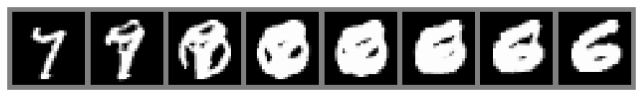

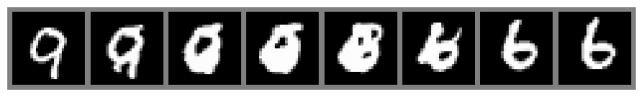

In [41]:
pl.seed_everything(42)
for i in range(2):
    interpolate(flow_dict["vardeq"]["model"], exmp_imgs[2*i], exmp_imgs[2*i+1])

Seed set to 42


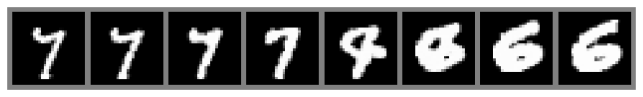

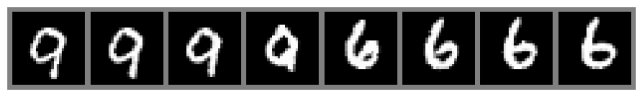

In [42]:
pl.seed_everything(42)
for i in range(2):
    interpolate(flow_dict["multiscale"]["model"], exmp_imgs[2*i], exmp_imgs[2*i+1])

### Interpolation Results and Interpretation

By inspecting the interpolations, we can observe a clear difference in the behavior of the two models:

- **Multi-scale model**: The interpolated images transition smoothly between digits (e.g., from a 7 to a 6). The intermediate images are realistic and resemble valid digits. This suggests that the model has successfully learned a globally coherent and smooth latent space. Even though some parts of the latent code were sampled rather than interpolated (due to the split operations in the architecture), the main visual identity of the digit is preserved and transitions meaningfully.
  
- **Variational dequantization model**: In contrast, while this model also performs smooth transitions in latent space, the intermediate images often look unrealistic or confusing. The latent representations seem to emphasize local pixel patterns rather than capturing the full digit identity. As a result, the interpolated samples fail to form digits that are easily recognizable to humans.

These findings highlight the strength of the multi-scale architecture in structuring the latent space and capturing high-level, semantically meaningful features. The split and squeeze operations effectively prioritize global structure, improving both interpolation and sampling quality.

### Visualizing the Role of Latent Variables at Different Scales

Now that we’ve seen how the multi-scale model can capture global image structures, let’s dig deeper into how the latent variables are distributed across the flow.

In a multi-scale architecture, some variables are split off early and directly modeled with the prior, while others continue to pass through more transformations. This raises a key question:

> What kind of information is captured by the early latent variables compared to those that remain deeper in the flow?

To explore this, we run the following experiment:
- We **fix the final latent variables** (i.e., those produced at the end of the flow, after all transformations).
- We **randomly resample the earlier split-off latent variables**.

If the final latent variables capture the essential, global structure of the digit, then all resulting samples should look quite similar at a high level (e.g., same digit identity), with differences in texture, stroke width, or style reflecting the variation in early latents.

Below, we generate and visualize 3 groups of 8 samples. Each group shares the same final latent variables but varies the earlier latent codes:


Seed set to 44


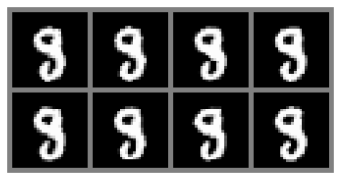

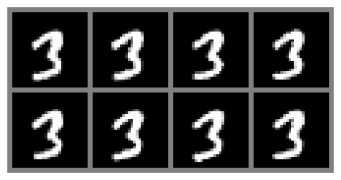

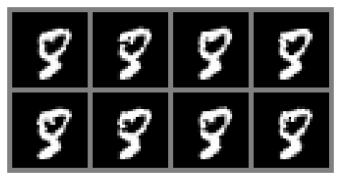

In [43]:
# Fixing the seed for reproducibility
pl.seed_everything(44)

# Repeat the experiment 3 times to observe variability
for _ in range(3):
    # Sample a single latent vector from the final latent space (shape: [1, 8, 7, 7])
    z_init = flow_dict["multiscale"]["model"].prior.sample(sample_shape=[1, 8, 7, 7])
    
    # Duplicate the same z vector 8 times (simulate fixing the final latents)
    z_init = z_init.expand(8, -1, -1, -1)
    
    # Sample 8 images that all share the same final latent variables
    # The randomness comes from the other latent variables split off earlier in the flow
    samples = flow_dict["multiscale"]["model"].sample(img_shape=z_init.shape, z_init=z_init)
    
    # Visualize the sampled images
    show_imgs(samples.cpu())

We observe that the latent variables split early in the multi-scale architecture have only a subtle influence on the overall image. While the generated digits share the same global structure — such as the identity of the digit — they still differ slightly in fine details.

For instance, in the second example (digit "3"), we can spot that the top loop of the digit varies slightly in its curvature and thickness across samples. These variations illustrate that early latents mostly capture local variations or noise-like details, while the final latent variables govern the high-level semantic content of the image — such as which digit is being generated.

This hierarchical representation is a desirable property of the multi-scale design: it allows later layers to focus on the most abstract features, and earlier layers to refine the image with local details.

### Visualizing Dequantization

As a final part of this notebook, we will take a closer look at the effect of **variational dequantization**. Earlier, we motivated its use by highlighting the limitations of uniform dequantization — in particular, the difficulty of modeling sharp edges or borders that arise from discrete pixel values.

Variational dequantization improves this by allowing the model to learn a **smooth, input-dependent distribution** over the noise values $u \sim q(u|x)$, rather than relying on a fixed uniform distribution. This added flexibility helps the model better match the smoothness of the Gaussian prior and avoid placing excess density around rigid discrete values.

To understand what kind of distribution the model has actually learned, we can visualize the output of the dequantization module by plotting a histogram over the dequantized values from a batch of images. This gives us empirical insight into how the noise is distributed and whether the model has learned to spread it smoothly across the support.

In [47]:
def visualize_dequant_distribution(model: ImageFlow, imgs: torch.Tensor, title: str = None):
    """
    Visualize the distribution of dequantized values from the first flow layer of the model.

    Parameters:
        model : ImageFlow
            The trained normalizing flow model.
        imgs : torch.Tensor
            A batch of input images (discrete integers in [0,255]).
        title : str, optional
            Title to display on the histogram.
    """
    imgs = imgs.to(device)
    ldj = torch.zeros(imgs.shape[0], dtype=torch.float32, device=device)

    # Accumulate dequantized outputs over multiple forward passes
    with torch.no_grad():
        dequant_vals = []
        for _ in tqdm(range(8), leave=False):
            dequantized, _ = model.flows[0](imgs, ldj, reverse=False)
            dequant_vals.append(dequantized)
        dequant_vals = torch.cat(dequant_vals, dim=0)

    # Flatten to 1D for histogram
    dequant_vals = dequant_vals.view(-1).cpu().numpy()

    # Plot histogram of dequantized values
    sns.set()
    plt.figure(figsize=(10, 3))
    plt.hist(dequant_vals, bins=256, color=to_rgb("C0") + (0.5,), edgecolor="C0", density=True)
    if title is not None:
        plt.title(title)
    plt.xlabel("Dequantized value")
    plt.ylabel("Density")
    plt.tight_layout()
    plt.show()
    plt.close()

# Take a batch of example training images
sample_imgs, _ = next(iter(train_loader))

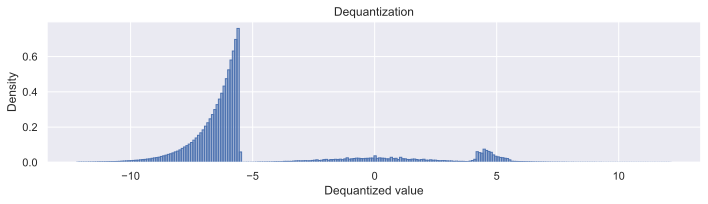

In [48]:
visualize_dequant_distribution(flow_dict["simple"]["model"], sample_imgs, title="Dequantization")

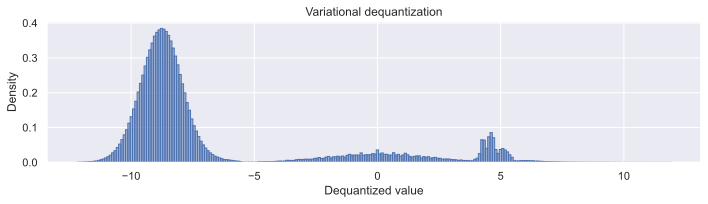

In [49]:
visualize_dequant_distribution(flow_dict["vardeq"]["model"], sample_imgs, title="Variational dequantization")

In the **first plot**, corresponding to standard dequantization, we observe a sharp spike in the histogram. This reflects the fact that MNIST images have a strong bias toward dark backgrounds (pixel value 0), and the uniform noise added during standard dequantization simply shifts those values slightly to the right. The resulting distribution still exhibits a clear discontinuity and sharp boundary, which the flow has to model despite its preference for smooth, continuous densities. This behavior can result in instability or inefficiency during training.

In contrast, the **second plot**, which corresponds to variational dequantization, shows a much smoother, bell-shaped curve. The model has learned to transform the original discrete values into a distribution that resembles a Gaussian. This not only makes the inputs more compatible with the Gaussian prior used in the latent space but also reduces the difficulty of learning invertible transformations. Importantly, the transformation has redistributed the pixel intensities in a way that avoids the hard boundary artifacts seen in the uniform case.

While this plot gives us a helpful 1D summary of the transformed inputs, it's important to remember that variational dequantization models a full, data-dependent distribution $q(u|x)$ in a high-dimensional space. Visualizing this in full would require inspecting a 784-dimensional joint distribution, which is not feasible directly. Still, the observed histogram strongly suggests that the learned noise distribution helps smooth and normalize the pixel distribution in a way that supports more effective flow training.

## Conclusion

In this notebook, we have learned how to implement a complete normalizing flow model and examined the key challenges that arise when applying flows to image data. A central issue is that normalizing flows operate in continuous space, whereas image pixels are discrete by nature. To bridge this gap, we introduced **dequantization**, which maps discrete images into a continuous space. While basic (uniform) dequantization prevents degenerate solutions like delta peaks, it creates rigid, hypercube-shaped regions that can be difficult for the flow to model.

We then extended this idea to **variational dequantization**, where the added noise is no longer uniform but sampled from a learnable distribution conditioned on the input image. This leads to smoother, more natural distributions that are easier for the flow to transform, and results in improved likelihood scores — measured in **bits per dimension (bpd)** — without impacting the speed of sampling.

Next, we explored the core building block of many normalizing flows: the **affine coupling layer**. Despite its simplicity, this layer is powerful and allows for efficient, invertible transformations with tractable Jacobians. By composing multiple coupling layers and using smart masking schemes (checkerboard and channel masks), we constructed flexible models that capture complex image statistics.

To scale up flows for high-dimensional data like images, we introduced the **multi-scale architecture**. By progressively splitting off and modeling latent variables at different resolutions using **squeeze** and **split** operations, we improved both efficiency and modeling capacity. The resulting models capture both local texture and global image structure more effectively.

Compared to VAEs, normalizing flows provide **exact likelihoods** in continuous space and guarantee that every possible input \( x \) has a corresponding latent representation \( z \). These properties make flows a compelling alternative for generative modeling — especially when interpretability, exact density estimation, or invertibility is important.

Finally, it's worth noting that the potential of normalizing flows goes well beyond image data. Flows have been successfully applied to **graph-structured data**, **molecular generation**, and more. Ongoing research in **continuous normalizing flows (CNFs)**, based on neural ODEs, opens the door to infinitely deep transformations, expanding the expressive power of these models even further.

In summary, normalizing flows are a powerful and versatile class of generative models, with solid theoretical foundations and growing practical impact. As both the theory and computational tools improve, they will likely play an increasingly important role in future machine learning systems.

## Useful References

[1] Dinh, L., Sohl-Dickstein, J., and Bengio, S. (2017). “Density estimation using Real NVP,” In: 5th International Conference on Learning Representations, ICLR 2017. [Link](https://arxiv.org/abs/1605.08803)

[2] Kingma, D. P., and Dhariwal, P. (2018). “Glow: Generative Flow with Invertible 1x1 Convolutions,” In: Advances in Neural Information Processing Systems, vol. 31, pp. 10215--10224. [Link](http://papers.nips.cc/paper/8224-glow-generative-flow-with-invertible-1x1-convolutions.pdf)

[3] Ho, J., Chen, X., Srinivas, A., Duan, Y., and Abbeel, P. (2019). “Flow++: Improving Flow-Based Generative Models with Variational Dequantization and Architecture Design,” in Proceedings of the 36th International Conference on Machine Learning, vol. 97, pp. 2722–2730. [Link](https://arxiv.org/abs/1902.00275)

[4] Durkan, C., Bekasov, A., Murray, I., and Papamakarios, G. (2019). “Neural Spline Flows,” In: Advances in Neural Information Processing Systems, pp. 7509–7520. [Link](http://papers.neurips.cc/paper/8969-neural-spline-flows.pdf)

[5] Hoogeboom, E., Cohen, T. S., and Tomczak, J. M. (2020). “Learning Discrete Distributions by Dequantization,” arXiv preprint arXiv2001.11235v1. [Link](https://arxiv.org/abs/2001.11235)

[6] Lippe, P., and Gavves, E. (2021). “Categorical Normalizing Flows via Continuous Transformations,” In: International Conference on Learning Representations, ICLR 2021. [Link](https://openreview.net/pdf?id=-GLNZeVDuik)